### Connecting SQL to Python

Keep the following in mind:

1. **Verify all required packages are installed**  
   Make sure you have installed the necessary libraries (e.g., `pyodbc`, `sqlalchemy`, `pymssql`, etc.) using `pip install`.

2. **Check the server name**  
   Confirm that the server name you are connecting to is correct. This may include the hostname, instance name, or IP address.

3. **Check the database name**  
   Ensure the database name in your connection string matches the actual database you want to access.

4. **Verify the SQL driver**  
   Most systems share common drivers, but always confirm which driver is available on your machine by checking through the terminal or command prompt.

In [1]:
import pyodbc

In [2]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'   # change to our server name
    'DATABASE=Customer_Churn;'               # the database we restored into
    'Trusted_Connection=yes;'
)

### See Available Tables in the Database

To list all tables in our database, you can query the system tables or use your database library’s built-in functions.  

In [3]:
import pandas as pd
query_tables = "SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE';"
tables = pd.read_sql(query_tables, conn)
tables

C:\Users\doaaa\AppData\Local\Temp\ipykernel_14176\2669543726.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)


,TABLE_NAME
0,sysdiagrams
1,Stage_Customer_Data
2,Stage_Date_Raw
3,Stage_Customer_Activity
4,Stage_PaymentMethod
5,Stage_Plan_Details
6,Customer
7,Plan_Details
8,PaymentMethod
9,Date


## EDA (Exploratory Data Analysis)

Exploratory Data Analysis helps us understand the structure, quality, and patterns within our customers dataset before building models or running deeper analysis.

In [4]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [5]:
import warnings
warnings.filterwarnings("ignore")  

In [6]:
# Check what tables exist within the DWH schema
query_tables = """
SELECT TABLE_NAME 
FROM INFORMATION_SCHEMA.TABLES 
WHERE TABLE_TYPE = 'BASE TABLE' 
  AND TABLE_NAME <> 'sysdiagrams'
  AND TABLE_SCHEMA = 'DWH'; -- <--- THIS IS THE KEY ADDITION
"""

tables = pd.read_sql(query_tables, conn)

tables

,TABLE_NAME
0,DimDate
1,DimPaymentMethod
2,DimPlan
3,DimCustomer
4,FactCustomerActivity


In [7]:
query = "SELECT * FROM DWH.FactCustomerActivity"
df = pd.read_sql(query, conn)
print("Data Loaded. Shape:", df.shape)
df.head()

Data Loaded. Shape: (7032, 11)


,Activity_ID,Customer_ID,Plan_ID,PaymentMethod_ID,Date_ID,Monthly_Charges,Total_Charges,Tenure_Months,Internet_Usage_GB,Calls_Minutes,Customer_Satisfaction_Score
0,A0000001,C000001,P001,PM002,20190117,29.85,29.85,1,11.44,14.0,7.7
1,A0000002,C000002,P002,PM004,20211217,56.95,1889.50,34,16.39,161.0,8.5
2,A0000003,C000003,P003,PM004,20211003,53.85,108.15,2,19.39,394.0,4.8
3,A0000004,C000004,P004,PM006,20230218,42.30,1840.75,45,20.31,19.0,6.8
4,A0000005,C000005,P005,PM002,20230702,70.70,151.65,2,69.53,108.0,3.4


In [8]:
print("Dataset shape:", df.shape)

Dataset shape: (7032, 11)


In [9]:
print("\nColumn data types:\n", df.dtypes)


Column data types:
 Activity_ID                     object
Customer_ID                     object
Plan_ID                         object
PaymentMethod_ID                object
Date_ID                          int64
Monthly_Charges                float64
Total_Charges                  float64
Tenure_Months                    int64
Internet_Usage_GB              float64
Calls_Minutes                  float64
Customer_Satisfaction_Score    float64
dtype: object


In [10]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Activity_ID                    0
Customer_ID                    0
Plan_ID                        0
PaymentMethod_ID               0
Date_ID                        0
Monthly_Charges                0
Total_Charges                  0
Tenure_Months                  0
Internet_Usage_GB              0
Calls_Minutes                  0
Customer_Satisfaction_Score    0
dtype: int64


## Joining the Tables

Before we start analyzing any patterns, we first need to join the relevant tables. This step is important because it lets us bring everything together connecting the customer’s activity with their demographic details and the churn flag. Once these tables are joined we can actually work with the full picture and move forward with the analysis.

In [11]:
query_analysis = """
SELECT 
    DC.Churn_Flag,
    FCA.Monthly_Charges,
    FCA.Tenure_Months,
    FCA.Internet_Usage_GB,
    FCA.Calls_Minutes,
    FCA.Customer_Satisfaction_Score,
    DP.Internet_Service_Type,
    DP.Tech_Support,
    DC.Gender,
    DC.Senior_Citizen,
    DC.Contract_Type
FROM 
    DWH.FactCustomerActivity FCA
JOIN 
    DWH.DimCustomer DC ON FCA.Customer_ID = DC.Customer_ID
JOIN 
    DWH.DimPlan DP ON FCA.Plan_ID = DP.Plan_ID;
"""

df_analysis = pd.read_sql(query_analysis, conn)
print("Analysis Data Loaded. Shape:", df_analysis.shape)
df_analysis.head()

Analysis Data Loaded. Shape: (7032, 11)


,Churn_Flag,Monthly_Charges,Tenure_Months,Internet_Usage_GB,Calls_Minutes,Customer_Satisfaction_Score,Internet_Service_Type,Tech_Support,Gender,Senior_Citizen,Contract_Type
0,False,29.85,1,11.44,14.0,7.7,dsl,False,female,False,month-to-month
1,False,56.95,34,16.39,161.0,8.5,dsl,False,male,False,one year
2,True,53.85,2,19.39,394.0,4.8,dsl,False,male,False,month-to-month
3,False,42.30,45,20.31,19.0,6.8,dsl,True,male,False,one year
4,True,70.70,2,69.53,108.0,3.4,fiber optic,False,female,False,month-to-month


## Analyze Patterns Across Features

Now that the data is joined, we can start looking for patterns across different features. For example, one clear trend we might see is that customers with high complaints and low satisfaction often end up churning. Identifying relationships like **high complaints → low satisfaction → churn** helps us understand what factors are driving customers to leave.

In [12]:
# Group by Satisfaction Score and calculate the average Churn Flag (where Churn_Flag = 1 means churn)
churn_rate_by_satisfaction = df_analysis.groupby('Customer_Satisfaction_Score')['Churn_Flag'].mean().reset_index()
churn_rate_by_satisfaction.rename(columns={'Churn_Flag': 'Churn_Rate'}, inplace=True)

(churn_rate_by_satisfaction)

,Customer_Satisfaction_Score,Churn_Rate
0,1.0,1.0
1,1.1,1.0
2,1.2,1.0
3,1.3,1.0
4,1.5,1.0
...,...,...
85,9.6,0.0
86,9.7,0.0
87,9.8,0.0
88,9.9,0.0


In [13]:
# Analyze the effect of Tech_Support on Churn
churn_rate_by_support = df_analysis.groupby('Tech_Support')['Churn_Flag'].mean().reset_index()

print("\nChurn Rate by Tech Support Status:")
(churn_rate_by_support)


Churn Rate by Tech Support Status:


,Tech_Support,Churn_Flag
0,False,0.312300
1,True,0.151961


In [14]:
# Count the occurrences of each class
churn_counts = df_analysis['Churn_Flag'].value_counts()

churn_percentages = df_analysis['Churn_Flag'].value_counts(normalize=True) * 100

print("Class Imbalance Report:")
print(f"\nCounts:\n{churn_counts}")
print("-" * 35)
print(f"Percentages:\n{churn_percentages.round(2)}")

Class Imbalance Report:

Counts:
Churn_Flag
False    5163
True     1869
Name: count, dtype: int64
-----------------------------------
Percentages:
Churn_Flag
False    73.42
True     26.58
Name: proportion, dtype: float64


## Churn Imbalance and High-Risk Categorical Features

This section provides visualizations that highlight the churn imbalance within our customer base, as well as the distribution of key categorical features associated with higher churn risk. These insights help us understand where disproportionate patterns occur and which groups may require closer attention during modeling.


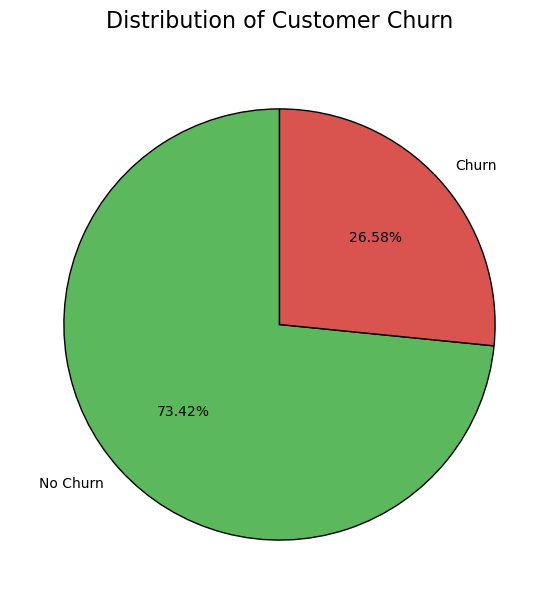

In [15]:
plt.figure(figsize=(7, 7))
df_analysis['Churn_Flag'].value_counts().plot.pie(
    autopct='%1.2f%%', 
    labels=['No Churn', 'Churn'], 
    colors=['#5cb85c', '#d9534f'], 
    startangle=90, 
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Distribution of Customer Churn', fontsize=16, pad=20)
plt.ylabel('')
plt.show()

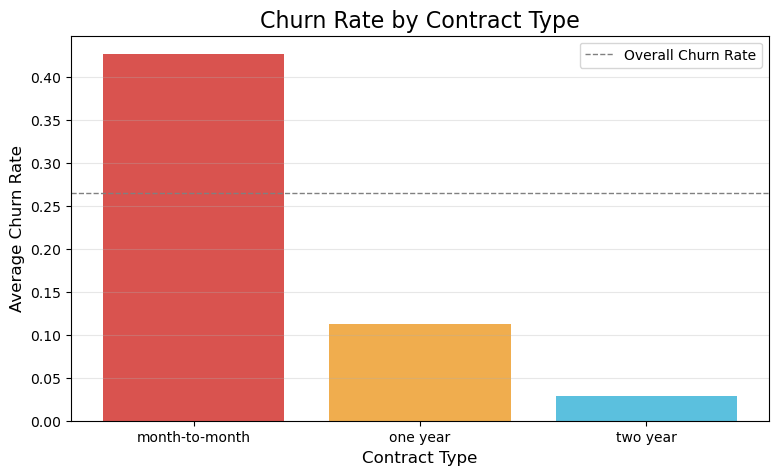

In [16]:
# Calculate the mean of Churn_Flag for each Contract Type
churn_rate_by_contract = df_analysis.groupby('Contract_Type')['Churn_Flag'] \
    .mean() \
    .sort_values(ascending=False) \
    .reset_index(name='Churn_Rate')

plt.figure(figsize=(9, 5))
plt.bar(
    churn_rate_by_contract['Contract_Type'], 
    churn_rate_by_contract['Churn_Rate'], 
    color=['#d9534f', '#f0ad4e', '#5bc0de'] # keep in mind that Red for highest, Yellow for middle, Blue for lowest
)
plt.axhline(df_analysis['Churn_Flag'].mean(), color='grey', linestyle='--', linewidth=1, label='Overall Churn Rate')
plt.title('Churn Rate by Contract Type', fontsize=16)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Average Churn Rate', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

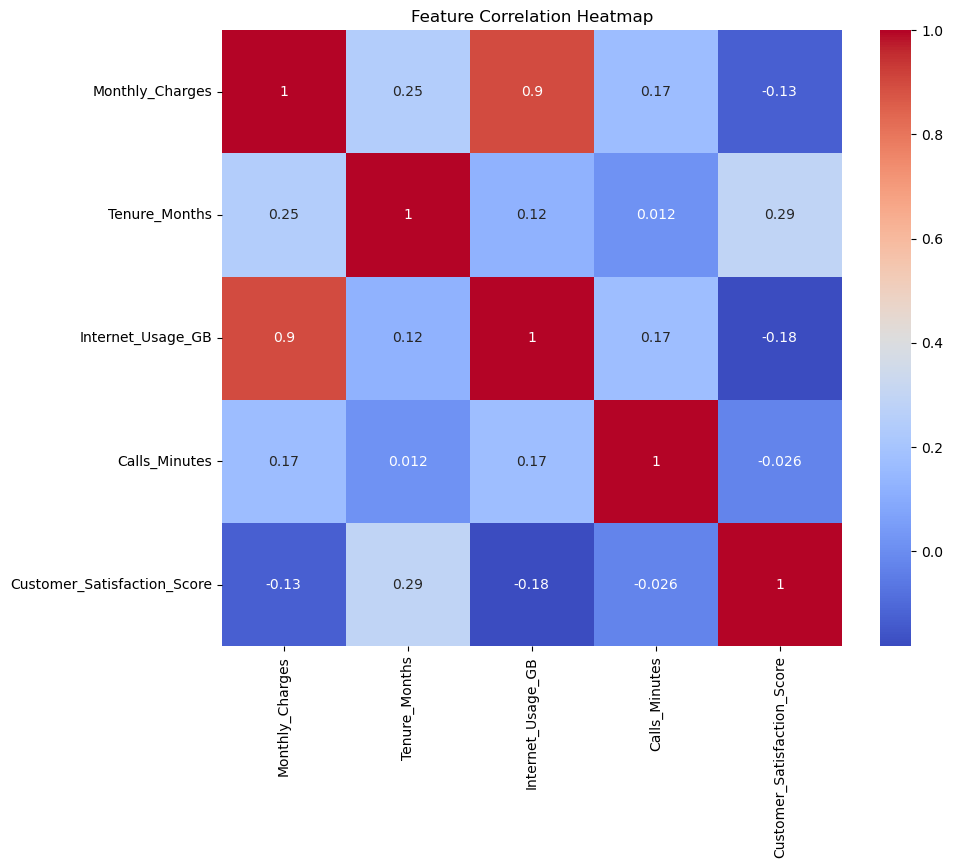

In [17]:
numeric_df = df_analysis.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

report_dir = '../Reports'
os.makedirs(report_dir, exist_ok=True)
heatmap_path = os.path.join(report_dir, 'correlation_heatmap_vlag.png')
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm', 
)
plt.title('Feature Correlation Heatmap')
plt.savefig(heatmap_path, bbox_inches='tight')
plt.show()


## Financial and Behavioral Distributions

This section illustrates the range, central tendencies, and overall distribution of continuous features derived from the Customer_Activity table. These visualizations help us better understand customer behavior by revealing spending patterns, activity frequency, and other key numerical trends that may influence churn.

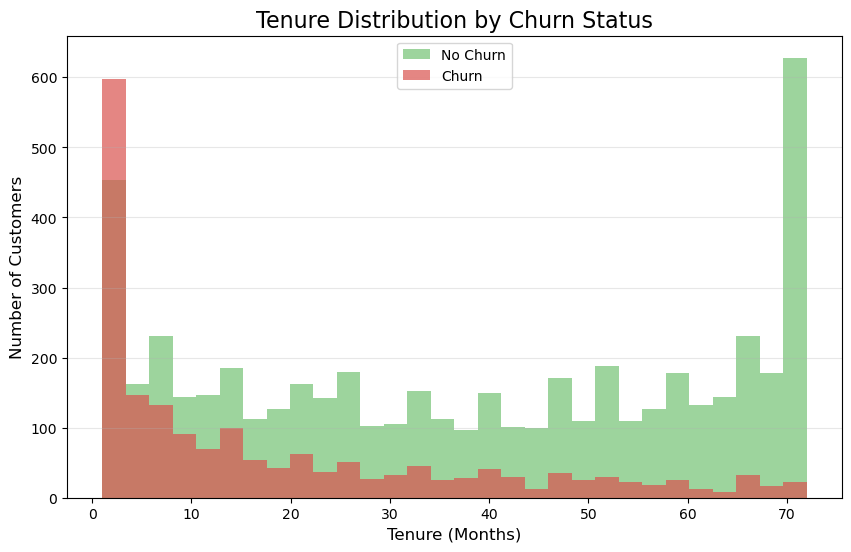

In [18]:
plt.figure(figsize=(10, 6))

# Histogram for customers who did NOT churn
plt.hist(
    df_analysis[df_analysis['Churn_Flag'] == 0]['Tenure_Months'], 
    bins=30, 
    alpha=0.6, 
    label='No Churn',
    color='#5cb85c'
)

# Histogram for customers who DID churn
plt.hist(
    df_analysis[df_analysis['Churn_Flag'] == 1]['Tenure_Months'], 
    bins=30, 
    alpha=0.7, 
    label='Churn',
    color='#d9534f'
)

plt.title('Tenure Distribution by Churn Status', fontsize=16)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

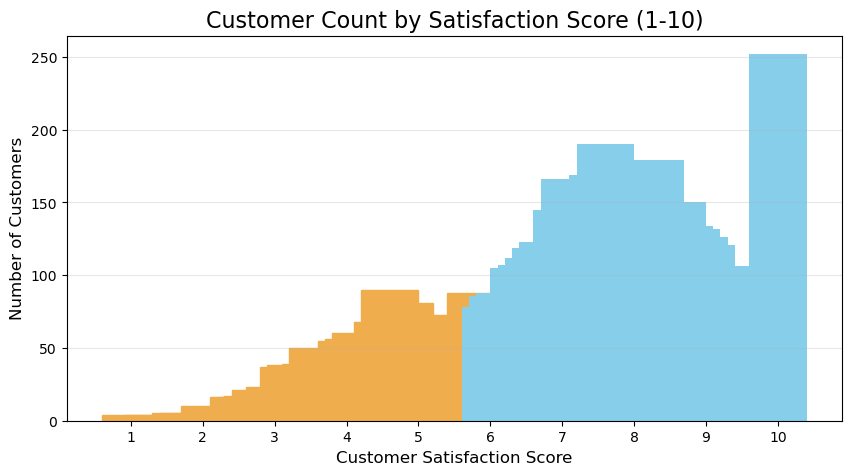

In [19]:
satisfaction_counts = df_analysis['Customer_Satisfaction_Score'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
bars = plt.bar(satisfaction_counts.index, satisfaction_counts.values, color='skyblue')

# Highlight scores below 6 
for i, bar in enumerate(bars):
    if satisfaction_counts.index[i] < 6: 
        bar.set_color('#f0ad4e') 

plt.title('Customer Count by Satisfaction Score (1-10)', fontsize=16)
plt.xlabel('Customer Satisfaction Score', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.xticks(range(1, 11))

plt.grid(axis='y', alpha=0.3)
plt.show()

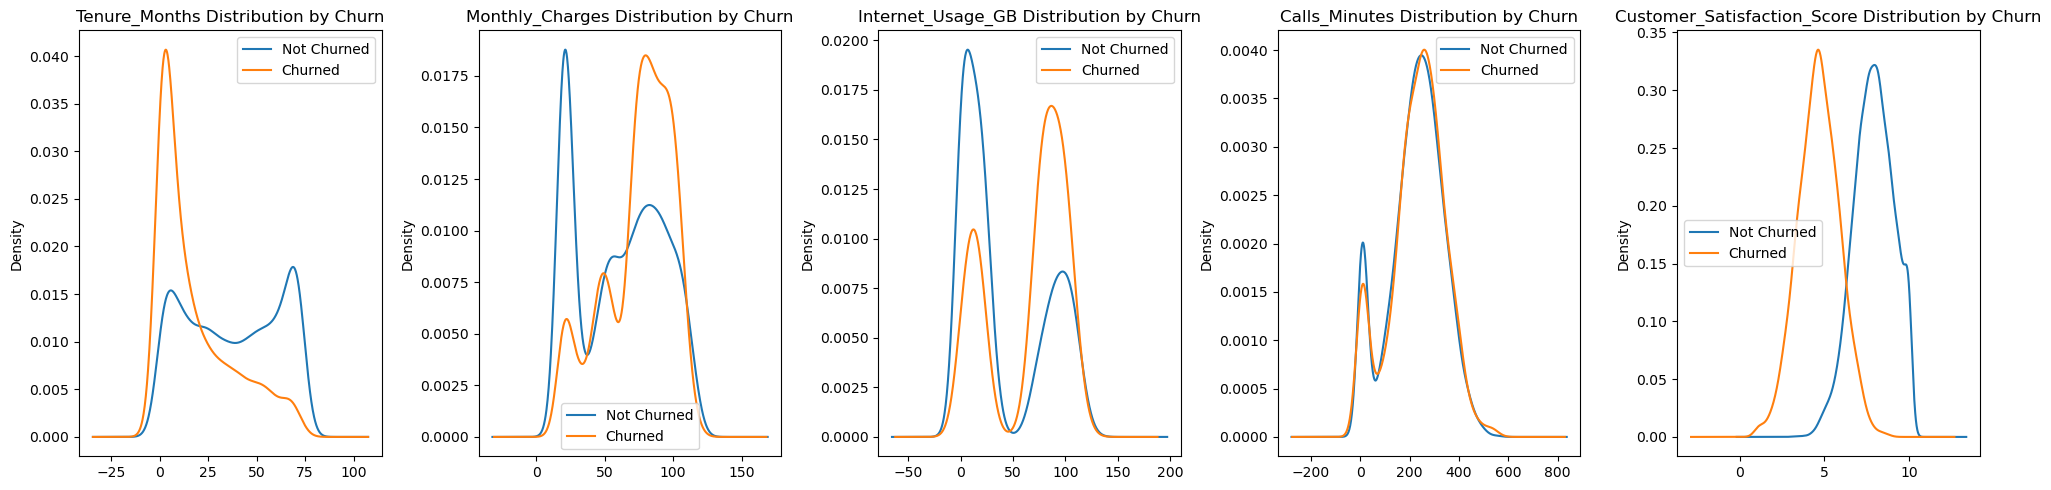

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  

numerical_to_plot = ['Tenure_Months', 'Monthly_Charges', 
                     'Internet_Usage_GB', 'Calls_Minutes', 
                     'Customer_Satisfaction_Score']

for i, col in enumerate(numerical_to_plot):
    ax = axes[i]
    for flag, label in zip([0, 1], ['Not Churned', 'Churned']):
        df_analysis[df_analysis['Churn_Flag'] == flag][col].plot(kind='kde', ax=ax)
    ax.set_title(f'{col} Distribution by Churn')
    ax.legend(['Not Churned', 'Churned'])

plt.tight_layout()
plt.show()


In [21]:
conn.close()
print("Connection closed.")


Connection closed.


### End of Milestone 1

We have successfully completed the first milestone of the project. Throughout this stage, we explored the dataset, integrated the necessary tables, and identified meaningful patterns that will inform our predictive strategy. With a strong analytical foundation in place, we are well-positioned to advance to the next phase.

**Thank you for the progress so far, we now proceed to the Modeling Milestone.**